In [5]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
def Perform_LQ_fit(sample, linear=False):
    #Generate LQ fit

    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations

    def Function(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

    x = np.array(sample['Dose'], dtype='float')
    y = np.array(sample['Mean Survival'], dtype = 'float')

    def bootstrap_fit(xdata, ydata, n_boot=1000):
        n = len(xdata)
        params = np.zeros([n_boot, 2])

        for b in range(n_boot):
            # resample indices with replacement
            idx = np.random.randint(0, n, n)

            x_resampled = xdata[idx]
            y_resampled = ydata[idx]

            if linear == True:
                bounds = (0, [1, 0.0001]) 
                p0 = (0.1, 0)
            if linear == False:
                bounds=(0,1)
                p0 = (0.1, 0.1)

            try:
                popt, pcov = curve_fit(Function, x_resampled, y_resampled, p0=p0, bounds=bounds)
                params[b,:] = popt
            except RuntimeError:
                # skip failed fits
                continue

        return params
    
    boot_params = bootstrap_fit(x, y, n_boot=2000)

    alpha_samples = boot_params[:, 0]
    beta_samples  = boot_params[:, 1]

    #Get 1 sigma confidence interval
    alpha_ci = np.percentile(alpha_samples, [16, 84])
    beta_ci  = np.percentile(beta_samples,  [16, 84])

    alpha_mean = np.mean(alpha_samples)
    beta_mean  = np.mean(beta_samples)

    print(f"alpha: {alpha_mean:.4f} [{alpha_ci[0]:.4f}, {alpha_ci[1]:.4f}]")
    print(f"beta : {beta_mean:.4f} [{beta_ci[0]:.4f}, {beta_ci[1]:.4f}]")
    
    return [alpha_mean, beta_mean], [alpha_ci[0], beta_ci[0]], [alpha_ci[1], beta_ci[1]]

In [9]:
data = pd.read_excel(r"..\Cell survival results\DATA RANDI.xlsx")

def LQ_func(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

params, low, up = Perform_LQ_fit(data)


alpha: 0.1500 [0.0645, 0.2377]
beta : 0.1238 [0.0957, 0.1531]


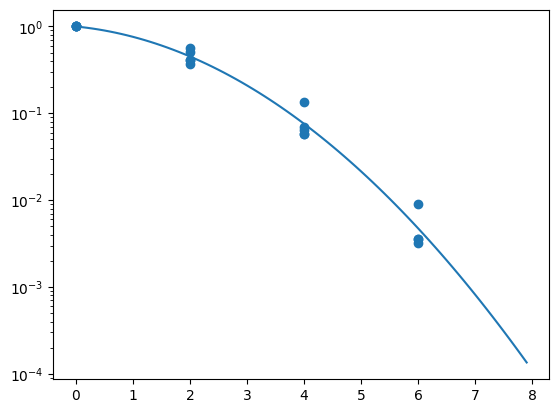

In [17]:
plt.scatter(data['Dose'], data['Mean Survival'])
plt.plot(np.arange(0,8,0.1), LQ_func(np.arange(0,8,0.1), params[0], params[1]))
plt.yscale('log')

In [18]:
data = pd.read_excel(r"..\Cell survival results\DATA RANDI CLONE.xlsx")

def LQ_func(d, a, b):
        return np.exp(-(a*d + b*(np.square(d))))

params, low, up = Perform_LQ_fit(data)

alpha: 0.1475 [0.0882, 0.2039]
beta : 0.1390 [0.1195, 0.1589]
